In [4]:
import sys
sys.path.append('../../')
import utils.funciones as fns
import numpy as np
import matplotlib.pyplot as plt
fns.formato_graficas()
import numpy as np

In [ ]:
# Carga de datos 
S1 = np.load(r"../../Data/dt_0.01/normalization_vectors.npz")['Z_norm']
S_dot1 = np.load(r"../../Data/dt_0.01/normalization_vectors.npz")['Z_dot_norm']

S2 = np.load(r"../../Data/dt_0.0005/normalization_vectors.npz")['Z_norm']
S_dot2 = np.load(r"../../Data/dt_0.0005/normalization_vectors.npz")['Z_dot_norm']

In [ ]:
# Vector separation (first 30 and last 30)
Sq_1, Sp_1 = S1[:30], S1[30:]
Sv_1, Sf_1 = S_dot1[:30], S_dot1[30:]

Sq_2, Sp_2 = S2[:30], S2[30:]
Sv_2, Sf_2 = S_dot2[:30], S_dot2[30:]

[ 0.00000000e+00 -2.39828695e-11  0.00000000e+00 -2.00203567e-04
 -1.20933990e-05 -4.75368264e-06 -1.60285267e-04 -1.16799827e-04
 -8.83499554e-06 -1.58285870e-04 -1.88355638e-04 -2.31280623e-06
 -1.66816578e-05 -1.02476492e-04 -5.38875997e-06 -3.12654036e-06
 -2.58241756e-06 -1.00471669e-07 -3.89774468e-06 -2.66423118e-06
 -9.89250774e-08 -9.99592579e-07 -1.13917423e-07 -3.51610963e-11
 -1.00030562e-09 -5.27764389e-07 -1.48455364e-08 -5.85591664e-09
 -9.59619229e-08 -5.59920643e-08]


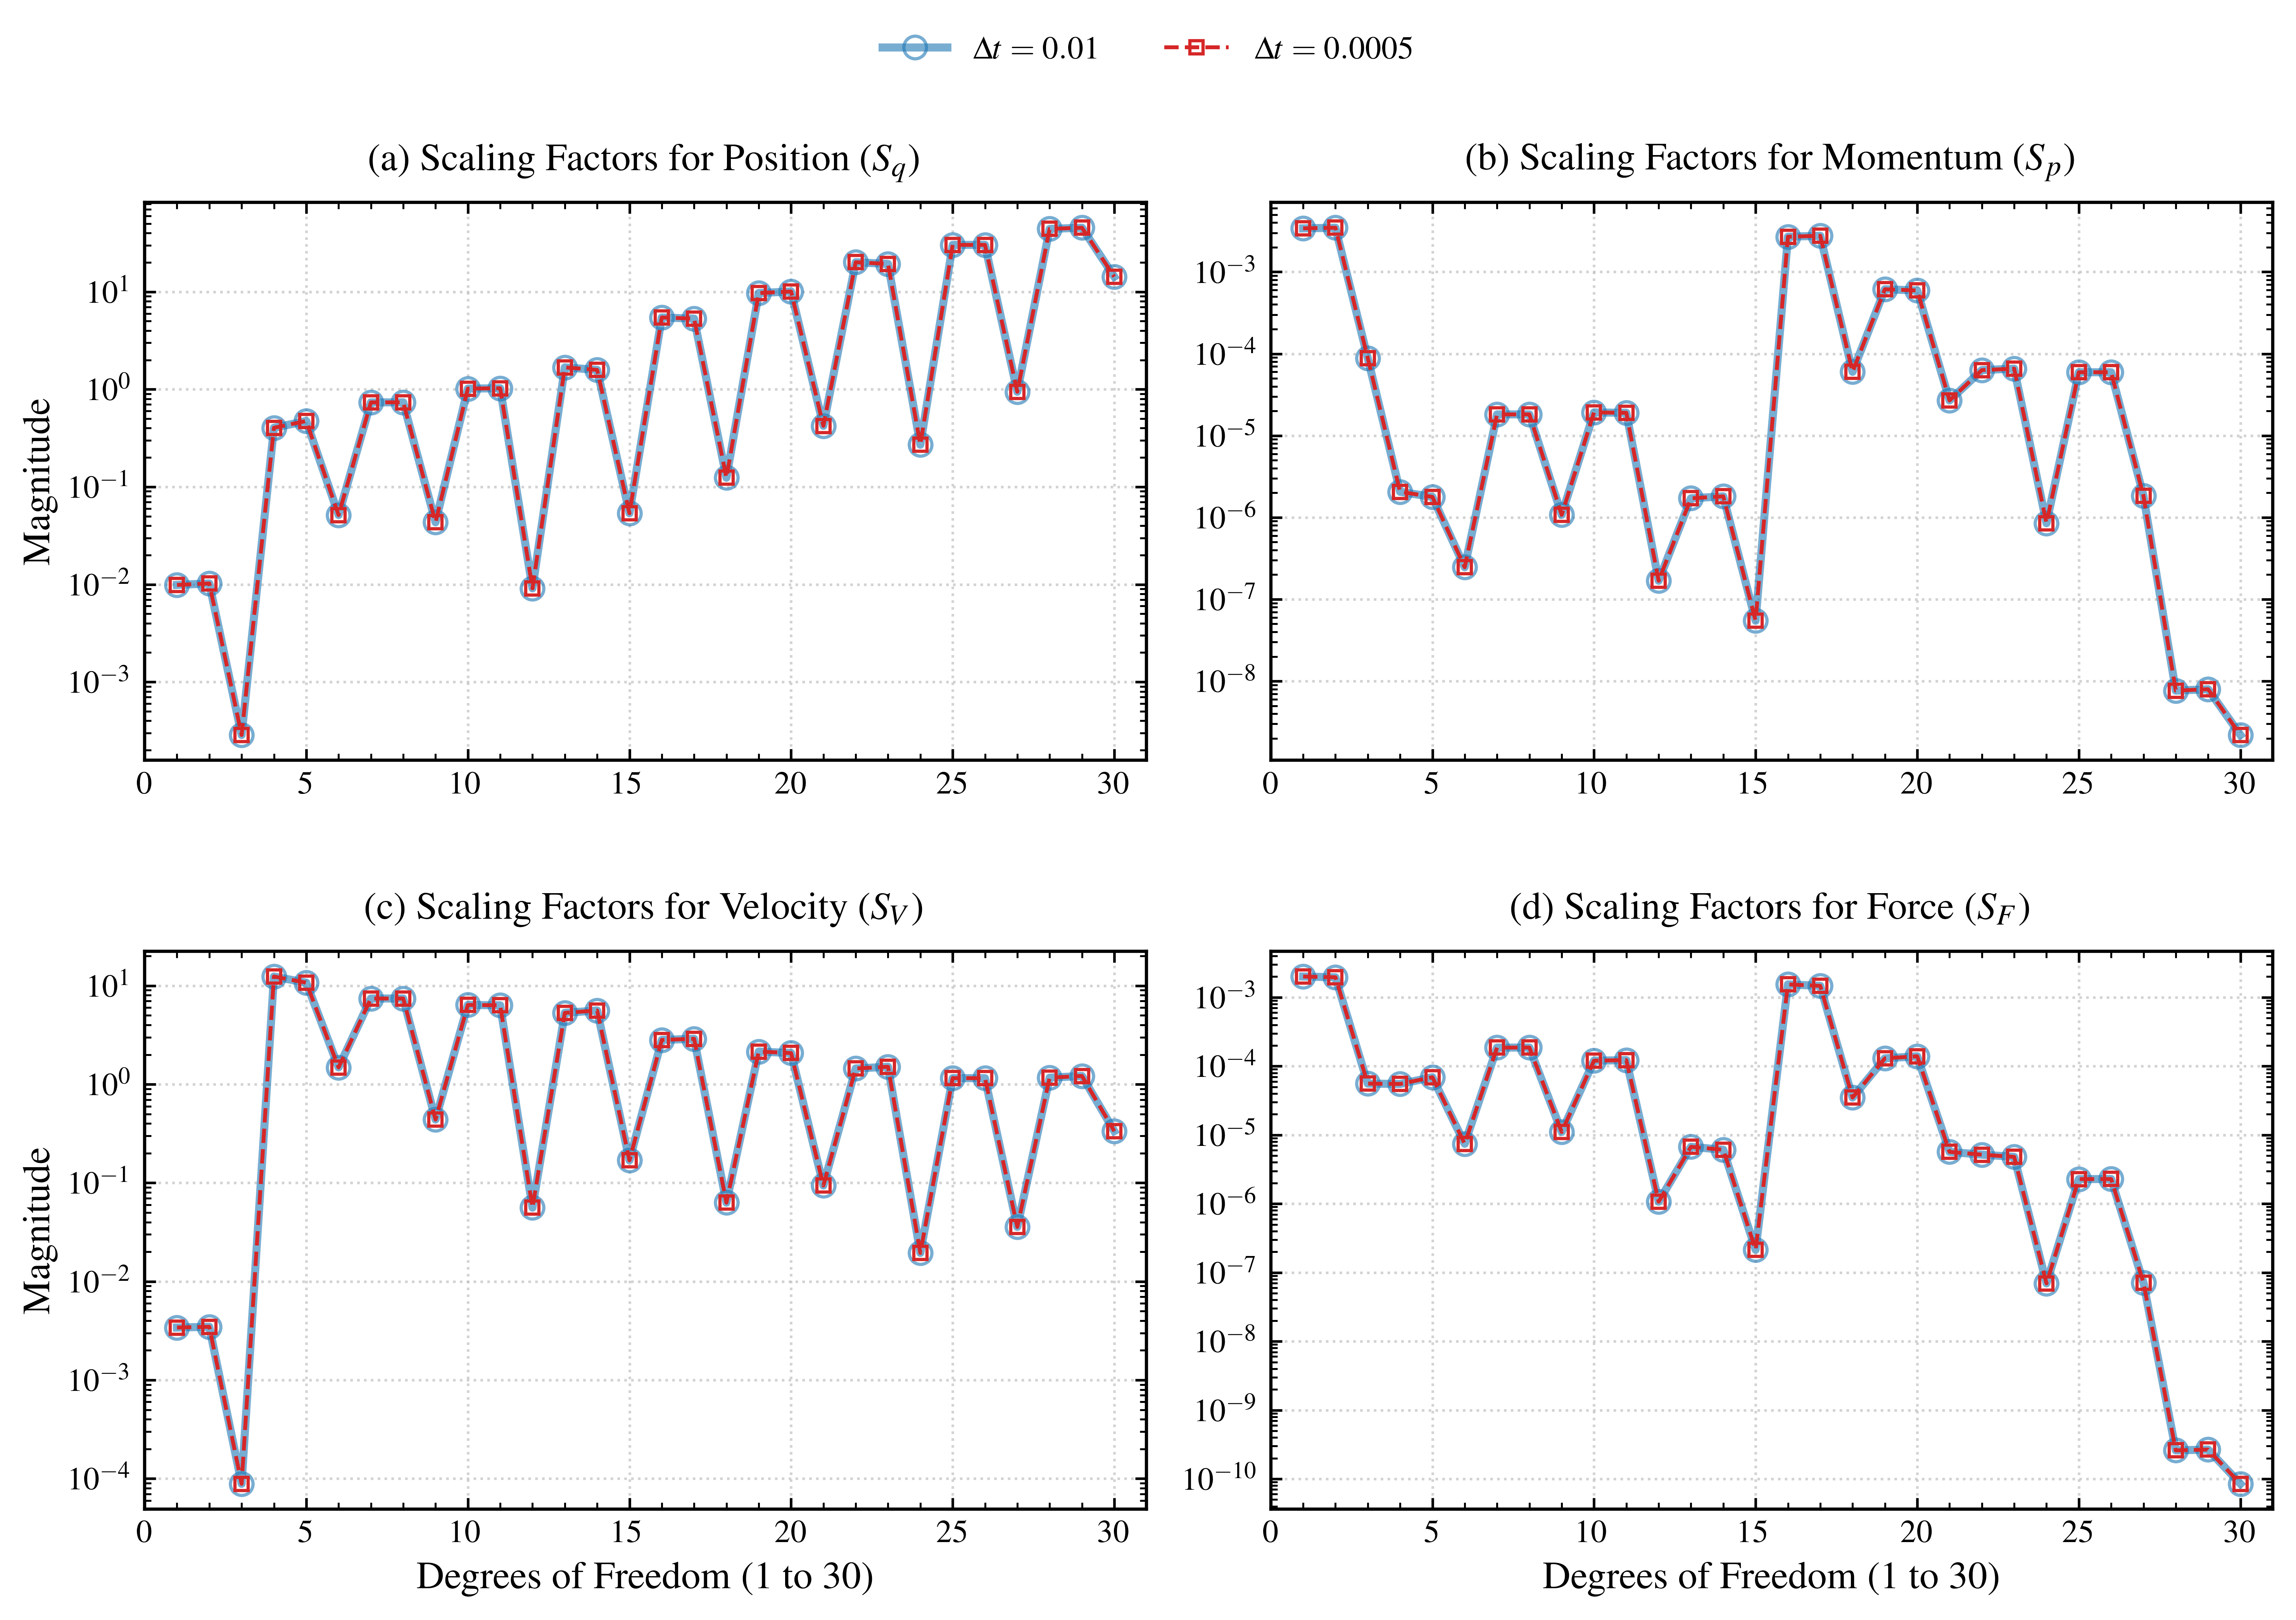

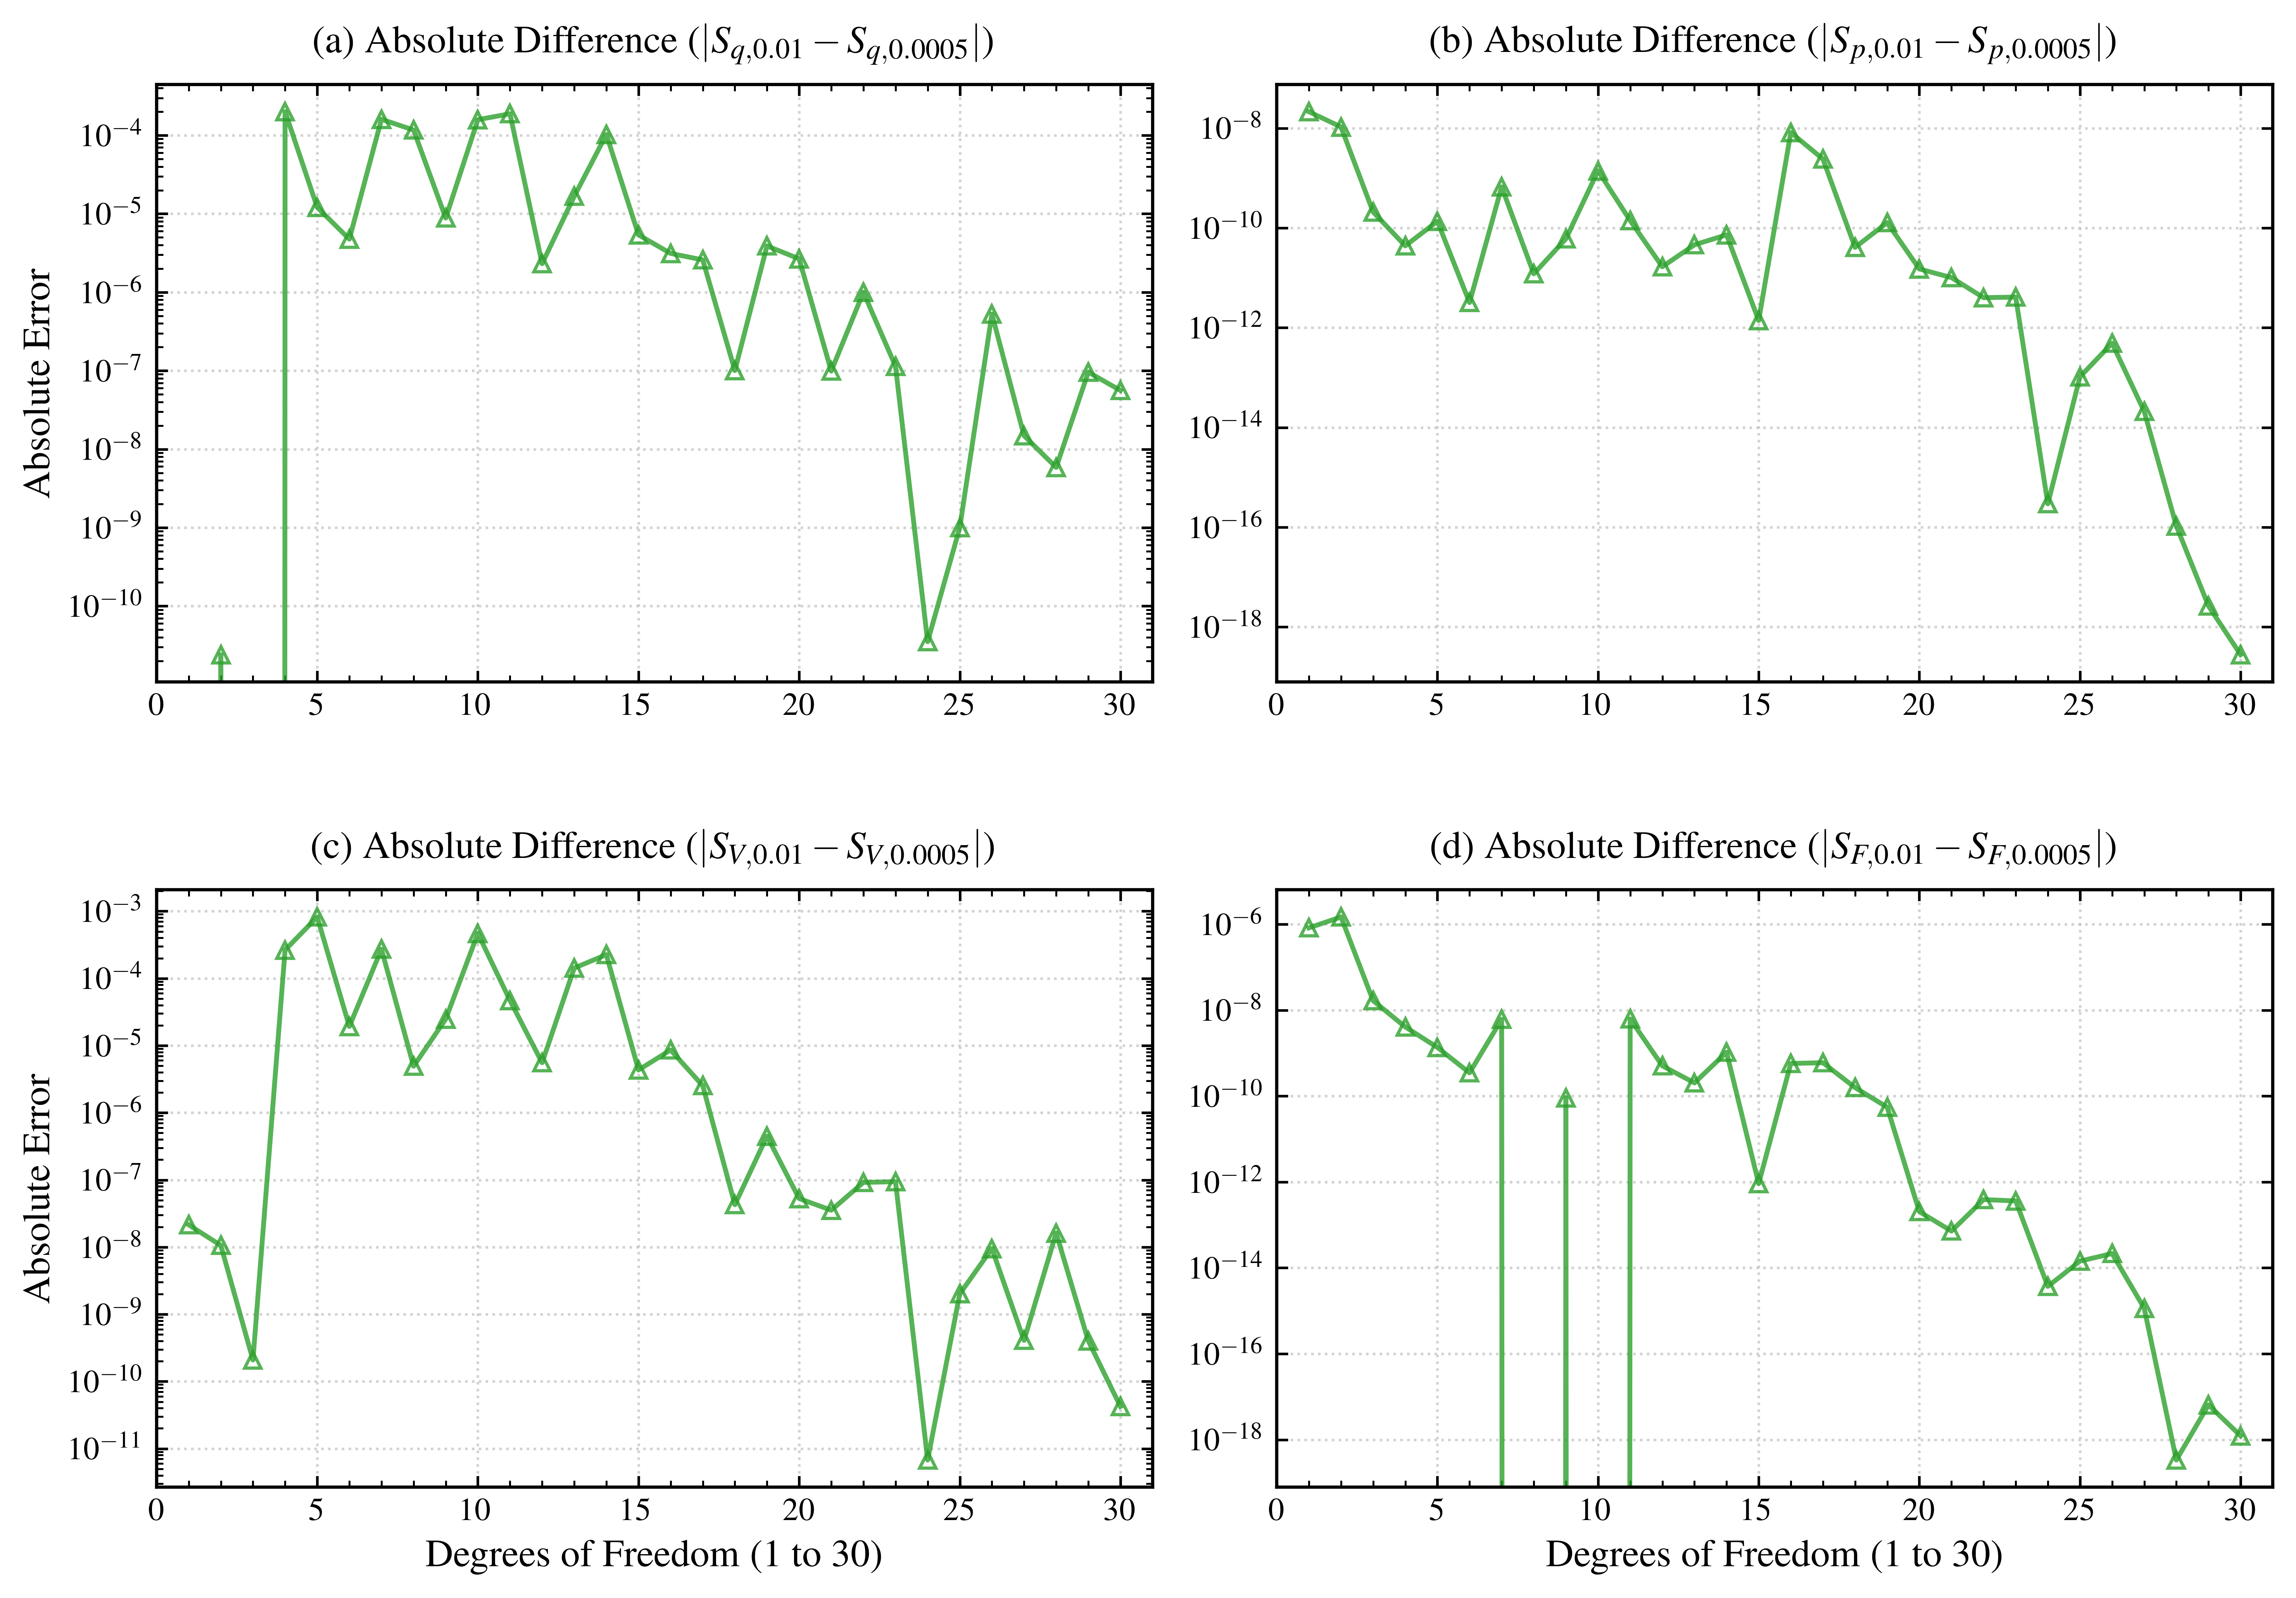

In [20]:
x = np.arange(1, 31)

fig1, axs1 = plt.subplots(2, 2, figsize=(10, 7), dpi=600)

c_dt1 = '#1f77b4'
c_dt2 = '#d62728'
m_dt1 = 'o'
m_dt2 = 's'

plot_configs_1 = [
    {
        'ax': axs1[0, 0], 'y1': Sq_1, 'y2': Sq_2, 
        'title': '(a) Scaling Factors for Position ($S_q$)', 
        'ylabel': 'Magnitude', 'xlabel': None
    },
    {
        'ax': axs1[0, 1], 'y1': Sp_1, 'y2': Sp_2, 
        'title': '(b) Scaling Factors for Momentum ($S_p$)', 
        'ylabel': None, 'xlabel': None
    },
    {
        'ax': axs1[1, 0], 'y1': Sv_1, 'y2': Sv_2, 
        'title': '(c) Scaling Factors for Velocity ($S_V$)', 
        'ylabel': 'Magnitude', 'xlabel': 'Degrees of Freedom (1 to 30)'
    },
    {
        'ax': axs1[1, 1], 'y1': Sf_1, 'y2': Sf_2, 
        'title': '(d) Scaling Factors for Force ($S_F$)', 
        'ylabel': None, 'xlabel': 'Degrees of Freedom (1 to 30)'
    }
]

for config in plot_configs_1:
    ax = config['ax']
    
    ax.plot(x, config['y1'], marker=m_dt1, markersize=7, linewidth=2.5, 
            color=c_dt1, linestyle='-', alpha=0.6, label=r'$\Delta t = 0.01$')
    
    ax.plot(x, config['y2'], marker=m_dt2, markersize=4, linewidth=1.2, 
            color=c_dt2, linestyle='--', markerfacecolor='none', label=r'$\Delta t = 0.0005$')
    
    ax.set_title(config['title'], pad=10)
    if config['ylabel']:
        ax.set_ylabel(config['ylabel'])
    if config['xlabel']:
        ax.set_xlabel(config['xlabel'])
        
    ax.set_yscale('log')
    ax.set_xlim([0, 31])
    ax.set_xticks(np.arange(0, 35, 5))
    ax.grid(True, linestyle=':', alpha=0.7)

handles, labels = axs1[0, 0].get_legend_handles_labels()
fig1.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1), frameon=False)

fig1.tight_layout(h_pad=3.0)
fig1.subplots_adjust(top=0.88)


fig2, axs2 = plt.subplots(2, 2, figsize=(10, 7), dpi=600)

diff_q = np.abs(Sq_1 - Sq_2)
diff_p = np.abs(Sp_1 - Sp_2)
diff_v = np.abs(Sv_1 - Sv_2)
diff_f = np.abs(Sf_1 - Sf_2)

plot_configs_2 = [
    {
        'ax': axs2[0, 0], 'y': diff_q, 
        'title': '(a) Absolute Difference ($|S_{q, 0.01} - S_{q, 0.0005}|$)', 
        'ylabel': 'Absolute Error', 'xlabel': None
    },
    {
        'ax': axs2[0, 1], 'y': diff_p, 
        'title': '(b) Absolute Difference ($|S_{p, 0.01} - S_{p, 0.0005}|$)', 
        'ylabel': None, 'xlabel': None
    },
    {
        'ax': axs2[1, 0], 'y': diff_v, 
        'title': '(c) Absolute Difference ($|S_{V, 0.01} - S_{V, 0.0005}|$)', 
        'ylabel': 'Absolute Error', 'xlabel': 'Degrees of Freedom (1 to 30)'
    },
    {
        'ax': axs2[1, 1], 'y': diff_f, 
        'title': '(d) Absolute Difference ($|S_{F, 0.01} - S_{F, 0.0005}|$)', 
        'ylabel': None, 'xlabel': 'Degrees of Freedom (1 to 30)'
    }
]

for config in plot_configs_2:
    ax = config['ax']
    
    ax.plot(x, config['y'], marker='^', markersize=5, linewidth=1.5, 
            color='#2ca02c', linestyle='-', alpha=0.8)
    
    ax.set_title(config['title'], pad=10)
    if config['ylabel']:
        ax.set_ylabel(config['ylabel'])
    if config['xlabel']:
        ax.set_xlabel(config['xlabel'])
        
    ax.set_yscale('log')
    ax.set_xlim([0, 31])
    ax.set_xticks(np.arange(0, 35, 5))
    ax.grid(True, linestyle=':', alpha=0.7)

fig2.tight_layout(h_pad=3.0)

plt.show()